**TASK 1**

In [4]:
import os
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
from PIL import Image

from google.colab import drive
drive.mount('/content/drive')


csv_path = "/content/drive/MyDrive/data.csv"
image_folder = "/content/drive/MyDrive/sampled_images"


df = pd.read_csv(csv_path)

df = df[["Filename", "AQI_Class"]]


df["image_path"] = df["Filename"].apply(
    lambda x: os.path.join(image_folder, x)
)


labels = df["AQI_Class"].unique()

label_to_idx = {l:i for i,l in enumerate(labels)}

df["label"] = df["AQI_Class"].map(label_to_idx)

num_classes = len(labels)



train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label"]
)



transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor()
])



class AQIDataset(Dataset):

    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        img_path = self.df.loc[idx, "image_path"]
        label = self.df.loc[idx, "label"]

        image = Image.open(img_path).convert("RGB")

        image = self.transform(image)

        return image, label



train_dataset = AQIDataset(train_df, transform)
val_dataset = AQIDataset(val_df, transform)
test_dataset = AQIDataset(test_df, transform)



train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)


print("Classes:", num_classes)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Classes: 6


**TASK 2**

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)



class BasicCNN(nn.Module):

    def __init__(self, num_classes):
        super(BasicCNN, self).__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 16 * 16, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):

        x = self.conv(x)
        x = self.fc(x)

        return x



model = BasicCNN(num_classes).to(device)


criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)



epochs = 3

train_losses = []
val_losses = []
train_accs = []
val_accs = []


for epoch in range(epochs):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        correct += (predicted == labels).sum().item()
        total += labels.size(0)


    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    train_losses.append(train_loss)
    train_accs.append(train_acc)


    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            correct += (predicted == labels).sum().item()
            total += labels.size(0)


    val_loss = running_loss / len(val_loader)
    val_acc = correct / total

    val_losses.append(val_loss)
    val_accs.append(val_acc)


    print(
        f"Epoch {epoch+1}/{epochs} "
        f"Train Loss {train_loss:.4f} "
        f"Val Loss {val_loss:.4f} "
        f"Train Acc {train_acc:.4f} "
        f"Val Acc {val_acc:.4f}"
    )



model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        correct += (predicted == labels).sum().item()
        total += labels.size(0)


test_acc = correct / total

print("Test Accuracy:", test_acc)

Device: cpu
Epoch 1/3 Train Loss 1.3804 Val Loss 1.1153 Train Acc 0.4395 Val Acc 0.5644
Epoch 2/3 Train Loss 0.9083 Val Loss 0.7425 Train Acc 0.6400 Val Acc 0.7100
Epoch 3/3 Train Loss 0.6064 Val Loss 0.5953 Train Acc 0.7757 Val Acc 0.7778
Test Accuracy: 0.7544444444444445


**TASK 3**

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)


# -------- LOAD PRETRAINED RESNET --------

model2 = models.resnet18(pretrained=True)


# freeze layers (transfer learning)

for param in model2.parameters():
    param.requires_grad = False


# replace final layer

in_features = model2.fc.in_features

model2.fc = nn.Linear(in_features, num_classes)


model2 = model2.to(device)


criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model2.fc.parameters(), lr=0.001)


epochs = 3

train_losses2 = []
val_losses2 = []
train_accs2 = []
val_accs2 = []


for epoch in range(epochs):

    model2.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model2(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        correct += (predicted == labels).sum().item()
        total += labels.size(0)


    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    train_losses2.append(train_loss)
    train_accs2.append(train_acc)


    model2.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model2(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            correct += (predicted == labels).sum().item()
            total += labels.size(0)


    val_loss = running_loss / len(val_loader)
    val_acc = correct / total

    val_losses2.append(val_loss)
    val_accs2.append(val_acc)


    print(
        f"Epoch {epoch+1}/{epochs} "
        f"Train Loss {train_loss:.4f} "
        f"Val Loss {val_loss:.4f} "
        f"Train Acc {train_acc:.4f} "
        f"Val Acc {val_acc:.4f}"
    )


# -------- TEST --------

model2.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model2(images)

        _, predicted = torch.max(outputs, 1)

        correct += (predicted == labels).sum().item()
        total += labels.size(0)


test_acc2 = correct / total

print("Pretrained Test Accuracy:", test_acc2)

Device: cpu
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:00<00:00, 104MB/s]


Epoch 1/3 Train Loss 1.2819 Val Loss 0.9344 Train Acc 0.5081 Val Acc 0.6522
Epoch 2/3 Train Loss 0.9782 Val Loss 0.8557 Train Acc 0.6369 Val Acc 0.6744
Epoch 3/3 Train Loss 0.8712 Val Loss 0.7757 Train Acc 0.6771 Val Acc 0.7011
Pretrained Test Accuracy: 0.7155555555555555


**TASK 4**

CNN RESULTS
Accuracy: 0.7544444444444445
Precision: 0.7778356535507706
Recall: 0.7544444444444444
F1: 0.7539383496540975


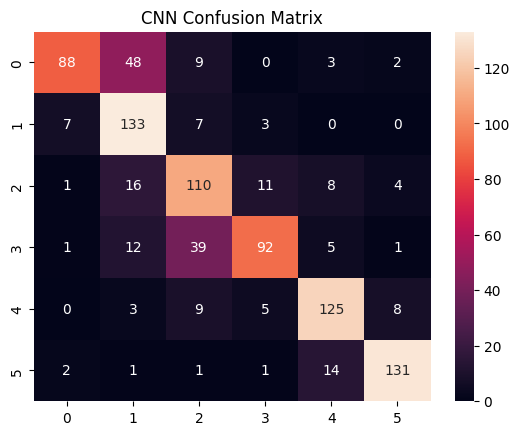

PRETRAINED RESULTS
Accuracy: 0.7155555555555555
Precision: 0.7202996190534713
Recall: 0.7155555555555555
F1: 0.7082019408688757


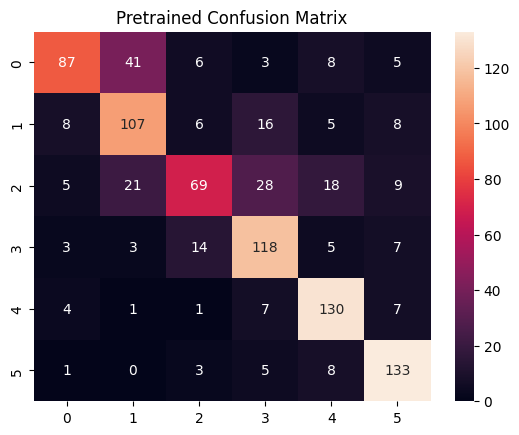

In [7]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def evaluate_model(model, loader):

    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

    return np.array(y_true), np.array(y_pred)

y_true1, y_pred1 = evaluate_model(model, test_loader)

acc1 = accuracy_score(y_true1, y_pred1)
prec1 = precision_score(y_true1, y_pred1, average="macro")
rec1 = recall_score(y_true1, y_pred1, average="macro")
f11 = f1_score(y_true1, y_pred1, average="macro")

print("CNN RESULTS")
print("Accuracy:", acc1)
print("Precision:", prec1)
print("Recall:", rec1)
print("F1:", f11)


cm1 = confusion_matrix(y_true1, y_pred1)

plt.figure()
sns.heatmap(cm1, annot=True, fmt="d")
plt.title("CNN Confusion Matrix")
plt.show()

y_true2, y_pred2 = evaluate_model(model2, test_loader)

acc2 = accuracy_score(y_true2, y_pred2)
prec2 = precision_score(y_true2, y_pred2, average="macro")
rec2 = recall_score(y_true2, y_pred2, average="macro")
f12 = f1_score(y_true2, y_pred2, average="macro")

print("PRETRAINED RESULTS")
print("Accuracy:", acc2)
print("Precision:", prec2)
print("Recall:", rec2)
print("F1:", f12)


cm2 = confusion_matrix(y_true2, y_pred2)

plt.figure()
sns.heatmap(cm2, annot=True, fmt="d")
plt.title("Pretrained Confusion Matrix")
plt.show()

**TASK 5**

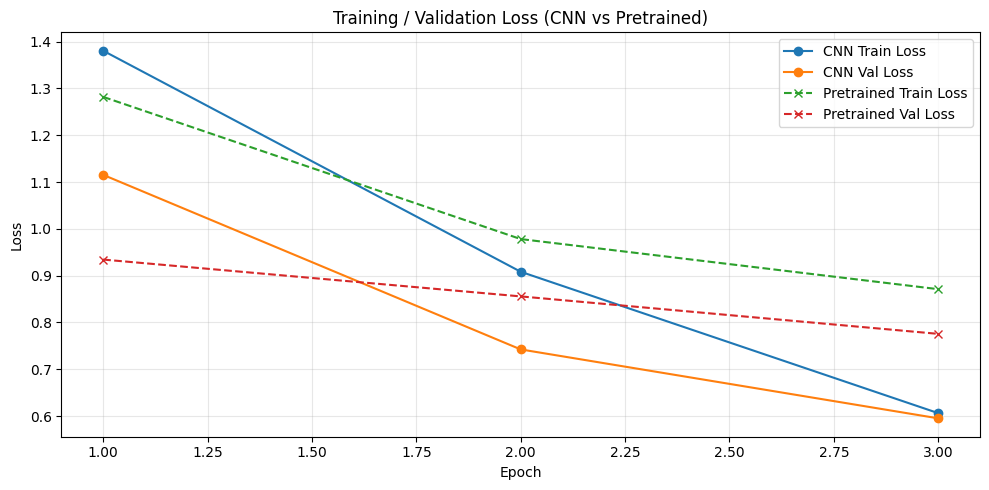

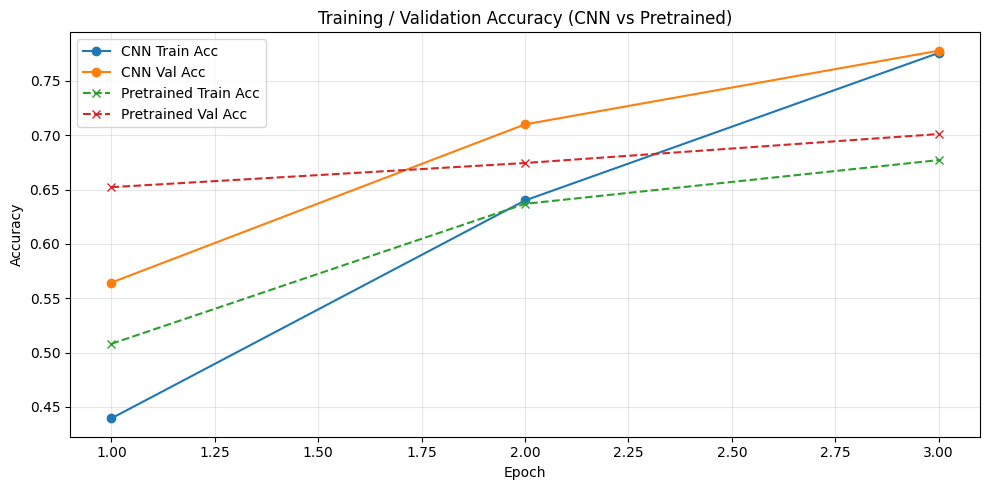

In [8]:
import matplotlib.pyplot as plt
import numpy as np

def _get(name, default=[]):
    return globals().get(name, default)

train_losses = _get("train_losses", [])
val_losses = _get("val_losses", [])
train_accs = _get("train_accs", [])
val_accs = _get("val_accs", [])
train_losses2 = _get("train_losses2", [])
val_losses2 = _get("val_losses2", [])
train_accs2 = _get("train_accs2", [])
val_accs2 = _get("val_accs2", [])

epochs_1 = list(range(1, max(1, len(train_losses)) + 1))
epochs_2 = list(range(1, max(1, len(train_losses2)) + 1))

plt.figure(figsize=(10,5))
if len(train_losses) and len(val_losses):
    plt.plot(epochs_1, train_losses, marker='o', label='CNN Train Loss')
    plt.plot(epochs_1, val_losses, marker='o', label='CNN Val Loss')
if len(train_losses2) and len(val_losses2):
    plt.plot(epochs_2, train_losses2, marker='x', linestyle='--', label='Pretrained Train Loss')
    plt.plot(epochs_2, val_losses2, marker='x', linestyle='--', label='Pretrained Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training / Validation Loss (CNN vs Pretrained)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("training_loss.png", dpi=150)
plt.show()

plt.figure(figsize=(10,5))
if len(train_accs) and len(val_accs):
    plt.plot(epochs_1, train_accs, marker='o', label='CNN Train Acc')
    plt.plot(epochs_1, val_accs, marker='o', label='CNN Val Acc')
if len(train_accs2) and len(val_accs2):
    plt.plot(epochs_2, train_accs2, marker='x', linestyle='--', label='Pretrained Train Acc')
    plt.plot(epochs_2, val_accs2, marker='x', linestyle='--', label='Pretrained Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training / Validation Accuracy (CNN vs Pretrained)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("training_acc.png", dpi=150)
plt.show()

**TASK 6**

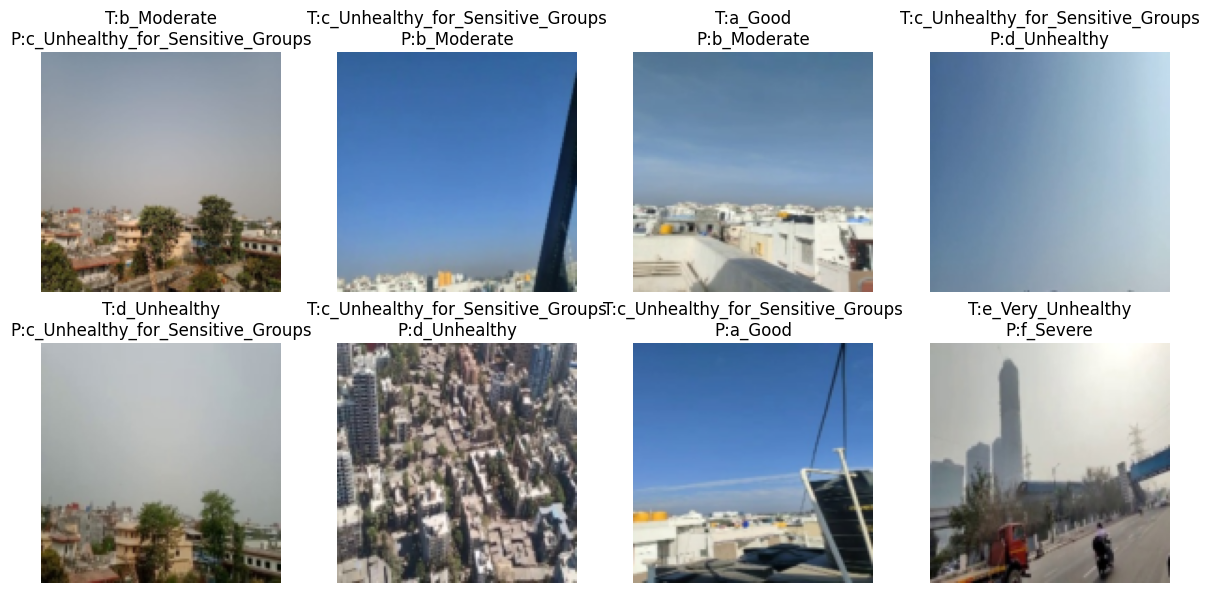

In [9]:
import torch
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

idx_to_label = {v:k for k,v in label_to_idx.items()}

model2.eval()

mis_images = []
mis_true = []
mis_pred = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model2(images)

        _, predicted = torch.max(outputs, 1)

        for i in range(len(labels)):

            if predicted[i] != labels[i]:

                mis_images.append(images[i].cpu())
                mis_true.append(labels[i].cpu().item())
                mis_pred.append(predicted[i].cpu().item())

            if len(mis_images) >= 8:
                break

        if len(mis_images) >= 8:
            break


plt.figure(figsize=(12,6))

for i in range(len(mis_images)):

    img = mis_images[i].permute(1,2,0).numpy()

    plt.subplot(2,4,i+1)
    plt.imshow(img)
    plt.axis("off")

    t = idx_to_label[mis_true[i]]
    p = idx_to_label[mis_pred[i]]

    plt.title(f"T:{t}\nP:{p}")

plt.tight_layout()
plt.show()

## Conclusion

In this lab, we implemented an image classification pipeline to predict AQI class from images using both a basic CNN and a pretrained CNN model. The basic CNN was trained from scratch, while the pretrained model used transfer learning with a ResNet architecture.

The CNN model achieved reasonable performance after training for a few epochs. The pretrained model also performed well, but it did not significantly outperform the CNN in this experiment. One possible reason is that the pretrained model was trained on ImageNet, which contains general images, while this dataset contains environmental images related to air quality. Because of this difference, the pretrained features were not perfectly suited for this task.

Transfer learning still helped the model learn faster, but better performance could be achieved by fine-tuning more layers or training for more epochs.

From the training curves, both models showed decreasing loss and increasing accuracy over epochs, which indicates that the models were learning correctly. The validation accuracy followed the training accuracy closely, so there was no strong overfitting.

From the confusion matrix, most predictions were correct along the diagonal, but some classes were confused with similar classes. This suggests that certain AQI categories have similar visual characteristics, making classification difficult.

In the misclassification analysis, some images were predicted incorrectly because the visual differences between classes were small, lighting and weather conditions varied, and some images contained mixed features from multiple AQI categories.

Overall, this lab demonstrates that deep learning models can classify environmental images with good accuracy, and pretrained models can be useful, but their performance depends on how similar the new dataset is to the data used during pretraining.